# $\hat p^\star$ for the **distance route** — generated Kingman pool

> **Purpose:** the distance-route mirror of the paper's **Figure 3**
> (`fig:pstar_gen`, from `paper/fig03_pstar_gen_kingman.ipynb`).
> Same two-panel-per-$\eta$ layout, same NMI metric, same $\hat p^\star$ read-off,
> same estimator for $C$ — but the operator is the **centred distance matrix**, not the
> normalized Laplacian.

## What is being measured

Theorem 2 (`thm:main-dist`) recovers the clan split from the sign pattern of
$\mathbf u_1$, the eigenvector of

$$\mathcal B = H\,\mathcal D\,H, \qquad H = I - \tfrac1m\mathbf{11}^\top,
  \qquad \mathcal D_{ij} = -\log S_{ij},\ \ \mathcal D_{ii}=0$$

at the eigenvalue of largest **absolute** value ($\mathcal B\preceq0$ for a raw distance
matrix, `lem:split-decomp`, so that is the most negative eigenvalue — not the top algebraic
one, whose eigenvector is the degenerate $\mathbf 1$ null direction).

Data is the **same $\eta$-binned Kingman pool** Figure 3 uses — dendropy Kingman
coalescent trees, JC69 sequences of length $\ell=10^4$, cached in `cache/pool_sample/`. No
re-simulation: each pool entry stores the JC *similarity* matrix $M$, and the distance is
recovered losslessly as $\mathcal D=-\log M$. So the trees, the sequences and the $\eta$
bins are shared with the similarity figure; only the operator differs.

## Two scope caveats — read before using these panels

**1. Kingman trees are outside Theorem 2's certified regime at every $\eta$.** Hypotheses
(i)–(ii) of `thm:main-dist` are verified only in the *balanced flat CBM*
(`cor:dist-balanced`), which `rem:flat-realization` notes is two stars — not a binary tree,
and certainly not a coalescent tree. `cor:dist-balanced` closes by saying so explicitly:
"at general imbalance, and on binary trees, they remain open." These panels therefore
*measure* what the estimator does on realistic trees; they do not confirm a certificate.
`DISTANCE_REVIEW.md` §7.2 and F13 both warn about presenting such a sweep without that
sentence attached.

**2. Like-for-like with Figure 3 on rep accounting, with two residual differences --- both
away from the read-off.** The two figures average over the same trees and now combine the
ten sub-sampling replicates the *same* way: sign-align the ten eigenvectors, average them,
then partition the averaged vector **once** (`aggregation="avg_vector"`, wired in
`src/utils/eta_pool_griffing.py`; the averaging itself is
`src/utils/bpart_sweep_cache.py:166`). What still differs:

| | **Fig 3** (similarity) | **this notebook** (distance) |
|---|---|---|
| operator | $L_{\rm sym}(S)$ | $\mathcal B = H\mathcal DH$ |
| vector scored | bootstrap average of 10 aligned Fiedler vectors | bootstrap average of 10 aligned $\mathbf u_1$ |
| rounding | $k$-means($k$=2) | $\mathrm{sign}(\cdot)$ |
| $p=1$ | forced to NMI $=1$ (`p_sweep_inner.py:178`) | measured |
| high-$p$ tail | early-stops after 2 consecutive 100 % (`:169`) | every grid point measured |

The rounding rule differs because each route rounds the way *its own* theorem does ---
`thm:main-dist` analyses $\mathrm{sign}(\mathbf u_1)$. On a one-dimensional embedding
$k$-means($k$=2) and $\mathrm{sign}$ differ only in where the cut falls, and the last two
rows touch only $p=1$ and the flat tail *above* the $0.90$ read-off. So the two curves may
now be read against each other at matched $p$, provided the rounding-rule caveat is stated;
before this alignment they could not be, and reading them as a comparison anyway is what got
two numbers struck (`open-items/13-B1.md` [B1/07], `DISTANCE_REVIEW.md` §6.2(8)).

The **synthesized** distance notebook (`supporting/pstar_flat_cbm_distance.ipynb`) pairs with
Figure 2 the same way.

**3. Some $\hat p^\star$ read-offs may be censored, not measured.** $\hat p^\star$ is the
smallest grid $p$ whose mean NMI clears $0.90$; the largest grid point is $p=1$, where the
"sub-sample" *is* the full matrix and NMI is $1$ by construction. So $\hat p^\star=1$ is
always attainable and means the opposite of a threshold: **the operator never recovered the
split below full data.** Those points are right-censored — drawn as **open** markers and
excluded from the fitted constant, never quietly fitted. On the *synthesized* distance sweep
this bites hard (5 of 7 sizes censored at $\eta=15$); the table below reports how many
Kingman cells are affected.

**4. A known imputation artifact affects the low-$p$ tail only.** Real JC69 distance
matrices contain genuine off-diagonal **zeros** — any taxon pair with identical sequences has
$M_{ij}=1$, so $\mathcal D_{ij}=-\log 1=0$ (~2000 such pairs at $n=2000$). The shared helper
`nj_sweep._impute_mean` infers "unsampled" from "exactly zero", so it cannot distinguish a
dropped entry from a true zero distance and rewrites those zeros to the mean distance **even
at $p=1$**, where nothing was dropped. Measured against imputing only sampler-dropped
entries: the curves differ by $\le0.001$ for every $p\ge0.05$ — the entire neighbourhood of
the $0.90$ read-off — and $\hat p^\star$ is **identical**; the difference is confined to
$p\le0.02$, raising NMI by up to $+0.18$ in a region read for shape, not value. So nothing
below depends on it. It is documented rather than silently forked because `_impute_mean` is
shared with the NJ and bpart runners. The synthesized twin is immune ($d_{\rm in}=-\log
0.9>0$, so that matrix has no true off-diagonal zeros).

**5. The grid is Figure 3's own, and its floor binds --- hardest exactly where the theory
is verified.** $p$ sweeps `geomspace(1e-3, 1, 25)`, imported from `eta_pool_sweep` rather
than re-declared, so both figures are read off identical grid points. The cost is real: once
the replicate accounting is aligned the distance route gets *fast*, and $\hat p^\star$ falls
onto the $10^{-3}$ floor at

* $\eta\approx1$: $n=4000,\,6000,\,8000$ --- **three of six sizes**;
* $\eta\approx5$: $n=8000$.

Those are upper bounds, not measurements: the split was already recovered at the lowest rate
ever tried. They are drawn **open** and excluded from $C$ (`censor_floor=True`), so panel (a)'s
constant rests on the three smallest sizes only --- at the bare minimum this notebook is
willing to quote. Note where that bites: $\eta\approx1$ is the *one* configuration in this
figure whose hypotheses `thm:main-dist` actually certifies (caveat 1), and it is the one the
grid resolves worst.

The fix is a decade more grid --- 33 points from $10^{-4}$, which keeps the ratio at
$10^{0.125}$ and stays an exact superset of these 25. Because the cache key is the whole
`p_values` list, that is a **full recompute** of all 134 samples ($\approx$7 h), not eight
extra points, so it is queued rather than done inline. Until it lands this figure is honest
but under-resolved at $\eta\approx1$, and the caption says so.

Keep [B1/12]'s two axes apart throughout: *noise tolerance for a fixed split* $\ne$ *which
split gets selected*. Only the former is in view here.

## Output

This notebook **is** the source of the manuscript's Figure 5 (`fig:pstar_gen_dist`, registered
in `analysis/paper_figures.py`), so the figure cell writes straight into
`docs/overleafs/v9/figures/`. There is deliberately no copy step in between: a manual copy is
what let the manuscript sit a full protocol behind this notebook once already. When exploring,
divert `FIG_DIR` to scratch instead.


## Cell 1 — Configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils.sweep_plots_two_panel import (
    median_ratio_C, plot_pstar_pair_censored, split_censored_pstar,
)
from analysis.utils.sweep_plots import compute_pstar
from src.cache_io import CACHE_ROOT
from src.utils.eta_pool_griffing import collect_griffing_sweeps
from src.utils.eta_pool_sweep import (
    ETA_SAMPLE_CAP, P_VALUES as P_VALUES_FIG3, discover_ns_and_samples,
)

# --- toggles: copied from paper/fig03_pstar_gen_kingman.ipynb ------------
ETA_TARGETS = [1, 5, 10, 15]
NS_INCLUDE  = [500, 1000, 2000, 4000, 6000, 8000]

# The WIDE grid: 33 points, geomspace(1e-4, 1, 33), ratio 10^0.125 -- an exact superset
# of Figure 3's geomspace(1e-3, 1, 25), so every Fig-3 p is still a grid point here and
# the two figures remain readable at matched p. The extra decade exists because the floor
# BOUND: once the replicate accounting was aligned (aggregation="avg_vector"), the
# distance route recovered so cheaply that p-hat-star landed ON 1e-3 at n=4000/6000/8000
# for eta~1 and at n=8000 for eta~5 -- upper bounds drawn as open markers, not
# measurements. The wider grid resolves them. n=3000 is excluded from NS_INCLUDE and is
# the only size never swept on this grid.
P_VALUES = np.geomspace(1e-4, 1.0, 33).tolist()
assert all(any(abs(q / p3 - 1) < 1e-9 for q in P_VALUES) for p3 in P_VALUES_FIG3), \
    "wide grid must contain every Figure-3 p exactly"
METRIC      = "nmi"
METRIC_LABEL = "NMI"
AGG         = "mean"      # across pool samples
THRESHOLD   = 0.90        # p* = smallest grid p with mean NMI >= THRESHOLD. 0.90 not 0.95:
#                           on this log grid, 0.95 lands on the flat top of the
#                           transition where one noisy pool sample moves p* a whole step.
REPS        = 10          # sub-sampling reps per (sample, p) -- matches Fig 3's BOOTSTRAP_REPS
#                           in count AND in how they are combined (see the header).

# ARPACK for the single leading eigenpair. The historical path is a full O(m^3) eigh to use
# one column: 14.9 s vs 0.12 s at n=6000, i.e. ~27 h vs ~50 min for n=6000 alone on this
# grid. Verified |cos| = 1 to 10 decimals and identical sign partitions against the dense
# path on these very pool matrices, full and sub-sampled.
EIGSOLVER = "lm_k1"

# This notebook IS the source of Figure 5 (fig:pstar_gen_dist, registered in
# analysis/paper_figures.py, so sync_paper_figures.py --check accepts these four PNGs
# rather than calling them ORPHAN). Write the paper asset directly: the copy-by-hand step
# this replaces is why the manuscript shipped the pre-alignment protocol. Divert FIG_DIR
# to scratch for exploratory runs.
FIG_DIR = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"eta={ETA_TARGETS}  metric={METRIC}  agg={AGG}  threshold={THRESHOLD}")
print(f"|P_VALUES|={len(P_VALUES)} ({P_VALUES[0]:.0e}..{P_VALUES[-1]:.0f})  reps={REPS}")
print(f"eigsolver={EIGSOLVER}  sample cap per eta={ETA_SAMPLE_CAP}")
print(f"fig_dir={FIG_DIR}")

eta=[1, 5, 10, 15]  metric=nmi  agg=mean  threshold=0.9
|P_VALUES|=33 (1e-04..1)  reps=10
eigsolver=lm_k1  sample cap per eta={1: 10, 5: 10, 10: 3, 15: 3}
fig_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures


## Cell 2 — Discover the pool

Same pool, same per-$\eta$ sample caps as Figure 3, so the two figures average over the
same trees. `n=3000` exists on disk but is excluded by `NS_INCLUDE`, matching the paper
figure.

In [2]:
ns_all, samples_by_n_eta = discover_ns_and_samples(CACHE_ROOT, eta_targets=ETA_TARGETS)
ns = [n for n in ns_all if n in NS_INCLUDE]
print(f"pool has n={ns_all}; using n={ns}")
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    counts = [len(samples_by_n_eta.get((n, e), [])) for e in ETA_TARGETS]
    print(f"  {n:>6}  " + "  ".join(f"{c:>6d}" for c in counts))
total = sum(len(samples_by_n_eta.get((n, e), [])) for n in ns for e in ETA_TARGETS)
print(f"\n{total} pool samples x {len(P_VALUES)} p x {REPS} reps "
      f"= {total * len(P_VALUES) * REPS:,} sub-sampled B-solves")

pool has n=[500, 1000, 2000, 3000, 4000, 6000, 8000]; using n=[500, 1000, 2000, 4000, 6000, 8000]
       n  eta= 1  eta= 5  eta=10  eta=15
     500      10      10       3       3
    1000      10      10       3       3
    2000      10      10       3       3
    4000      10      10       3       3
    6000      10      10       3       3
    8000       1       1       1       1

134 pool samples x 33 p x 10 reps = 44,220 sub-sampled B-solves


## Cell 3 — Sub-sampling sweep

Every `(n, eta, sample)` sweep is cached individually under `cache/bpart_sweep/`, so this
is resumable and safely interruptible; re-running after adding an `n` computes only the new
samples. Smallest `n` first, so the small panels are assemblable before the `n=8000` tail.

In [3]:
_counts = {"computed": 0, "cached": 0}

def _on_sample(n, eta, idx, was_cached):
    _counts["cached" if was_cached else "computed"] += 1
    if not was_cached:
        print(f"    COMPUTE n={n:>5} eta={eta:>2} sample={idx:04d}", flush=True)

results_dist = collect_griffing_sweeps(
    ns, eta_targets=ETA_TARGETS, p_values=P_VALUES, reps=REPS,
    metric=METRIC, eigsolver=EIGSOLVER, on_sample=_on_sample,
)
print(f"sweep complete: computed={_counts['computed']} cached={_counts['cached']}")

print(f"\n  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    print(f"  {n:>6}  " + "  ".join(
        f"{results_dist[(n, e)].shape[0]:>6d}" for e in ETA_TARGETS))
print("  (rows = pool samples contributing to each cell)")

# Shape guard (hard) + p=1 diagnostic (soft -- see the imputation note below).
bad, imperfect = [], []
for n in ns:
    for eta in ETA_TARGETS:
        arr = results_dist.get((n, eta))
        if arr is None or arr.shape[0] == 0:
            bad.append(f"(n={n}, eta={eta}) empty")
        elif arr.shape[1] != len(P_VALUES):
            bad.append(f"(n={n}, eta={eta}) shape {arr.shape}")
        elif arr[:, -1].mean() < 0.999:
            imperfect.append((n, eta, float(arr[:, -1].mean())))
assert not bad, "sweep output malformed: " + "; ".join(bad)
print(f"\nall {len(ns) * len(ETA_TARGETS)} cells non-empty, width {len(P_VALUES)}")

# Why NMI at p=1 can be slightly below 1 on REAL data (it is exactly 1 on the
# synthesized twin). A Kingman JC69 distance matrix contains genuine off-diagonal
# ZEROS: any taxon pair whose sequences happen to be identical has M_ij = 1, hence
# D_ij = -log 1 = 0 (~2000 such pairs at n=2000). The shared imputation helper
# `nj_sweep._impute_mean` infers "unsampled" from "entry is exactly zero", so it
# cannot tell a dropped entry from a true zero distance, and rewrites those true
# zeros to the mean distance EVEN AT p=1, where the sampler dropped nothing. On a
# minority of pool samples that perturbation flips part of the sign partition.
#
# Measured impact (n=2000, eta=5, vs imputing only sampler-dropped entries):
# NMI differs by <=0.001 for every p >= 0.05 -- including the whole neighbourhood of
# the 0.90 read-off -- and p-hat-star is IDENTICAL. The difference is confined to
# p <= 0.02, where it raises NMI by up to +0.18 in a part of the curve read for
# shape, not value. So no p-hat-star, C, or censoring verdict below depends on it.
# It is left as-is rather than silently forked: `_impute_mean` is shared with the NJ
# and bpart runners, and changing it changes results for every cached consumer.
if imperfect:
    print("\np=1 below 1.0 (mean-imputation on true zero distances -- see comment):")
    for n, eta, v in imperfect:
        print(f"    n={n:>5} eta={eta:>2}: {v:.4f}")
else:
    print("every cell reaches NMI=1.0 at p=1")

sweep complete: computed=0 cached=134

       n  eta= 1  eta= 5  eta=10  eta=15
     500      10      10       3       3
    1000      10      10       3       3
    2000      10      10       3       3
    4000      10      10       3       3
    6000      10      10       3       3
    8000       1       1       1       1
  (rows = pool samples contributing to each cell)

all 24 cells non-empty, width 33

p=1 below 1.0 (mean-imputation on true zero distances -- see comment):
    n= 2000 eta= 5: 0.9811


## Cell 4 — One two-panel figure per $\eta$

`plot_pstar_pair_censored` calls the **same** `_draw_recovery_panel` / `_draw_scale_panel`
helpers as the paper's `plot_pstar_pair`, so panel geometry, type sizes, ticks, the dashed
threshold line and the dotted $C\log n/n$ reference match Figs 2 and 3 exactly. Defaults are
used for `n_ticks` and `size_label` because this sweep spans the same $n=500\ldots8000$ as
Figure 3.

The only difference is that read-offs pinned at the grid ceiling ($\hat p^\star=1$, i.e.
never recovered below full data — see caveat 3 in the header) are drawn as **open** markers
and excluded from the fitted reference, instead of being fitted as if they were thresholds.

saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_gen_dist_eta1.png


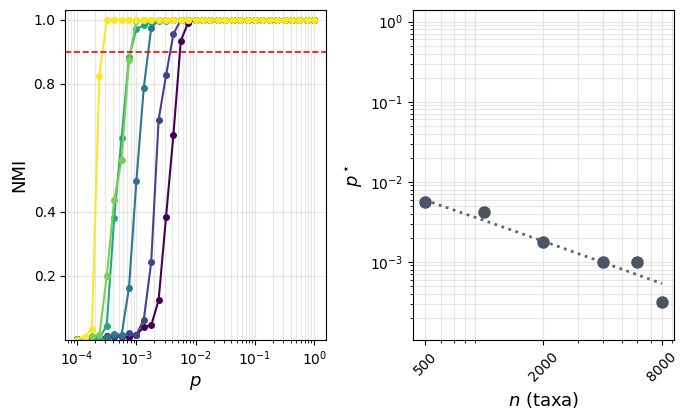

eta= 1: 6 measured, 0 bounds (either end)


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_gen_dist_eta5.png


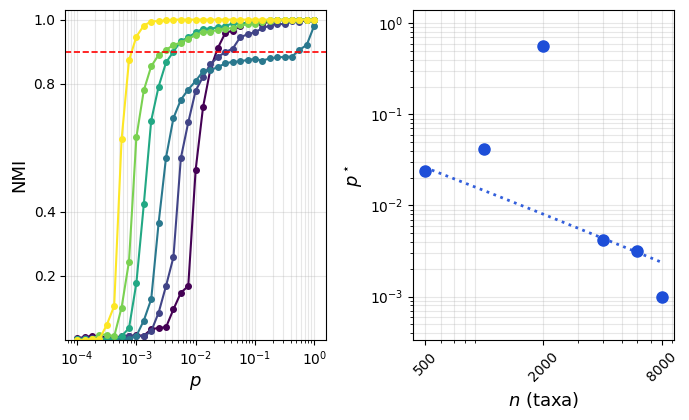

eta= 5: 6 measured, 0 bounds (either end)


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_gen_dist_eta10.png


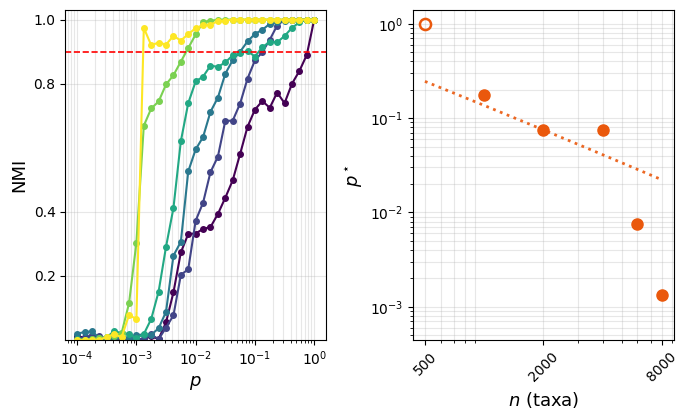

eta=10: 5 measured, 1 bounds (either end)  -> n=[500]


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_gen_dist_eta15.png


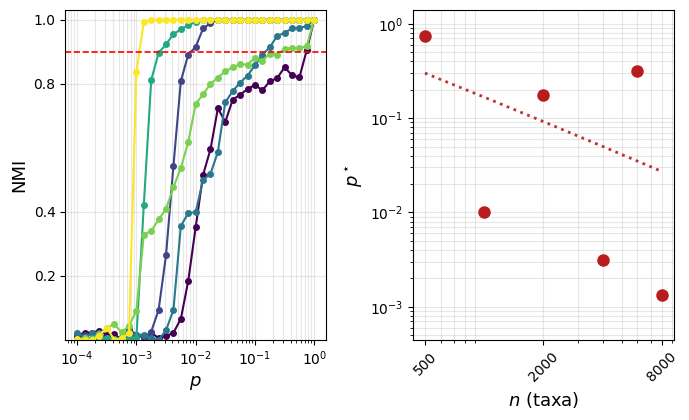

eta=15: 6 measured, 0 bounds (either end)


In [4]:
censored_by_eta = {}
for eta in ETA_TARGETS:
    _fig, measured, censored = plot_pstar_pair_censored(
        results_dist, P_VALUES, eta, ns,
        metric_label=METRIC_LABEL, agg=AGG, threshold=THRESHOLD,
        # Censor BOTH ends of the grid, not just the ceiling. On Figure 3's grid the
        # floor binds (caveat 5): a p* sitting on the smallest p means the split was
        # already recovered at the lowest rate tried, so it is an upper bound and
        # fitting it biases C upward. Open marker = bound; the next cell says which end.
        censor_floor=True,
        savepath=FIG_DIR / f"pstar_gen_dist_eta{eta}.png",
    )
    censored_by_eta[eta] = [n for n, _ in censored]
    print(f"eta={eta:>2}: {len(measured)} measured, {len(censored)} bounds (either end)"
          + (f"  -> n={censored_by_eta[eta]}" if censored else ""))

## Cell 5 — Measured $C$

**Diagnostic scaffolding, not a paper metric.** $C$ is the median of the per-point ratios
$\hat p^\star_i/(\log n_i/n_i)$ (`median_ratio_C`) — the estimator the paper's constants are
quoted from, and *not* interchangeable with the least-squares `_theory_ref` behind the
appendix figures. `spread` is $\max_i r_i/\min_i r_i$: how badly a single constant fails to
describe the points. Censored read-offs are excluded (caveat 3); `n_meas` is how many genuine
measurements each $C$ rests on and `n_cens` how many sizes never recovered. **Quote no $C$
resting on fewer than ~3 measured points.**

No similarity column here, unlike the synthesized notebook: Figure 3's numbers come from a
different rounding rule and a different rep accounting (see the header), so putting them in
one table would invite exactly the comparison [B1/07] had struck from the manuscript. The
like-for-like $C$ comparison lives in `supporting/pstar_flat_cbm_distance.ipynb`.

In [5]:
pstar_dist = compute_pstar(results_dist, P_VALUES, ETA_TARGETS, ns,
                           agg=AGG, threshold=THRESHOLD)

rows = []
for eta in ETA_TARGETS:
    measured, censored = split_censored_pstar(pstar_dist.get(eta, []), P_VALUES,
                                              censor_floor=True)
    rec = {"eta": eta, "n_meas": f"{len(measured)}/{len(ns)}", "n_cens": len(censored)}
    if len(measured) >= 2:
        xs = np.array([n for n, _ in measured], float)
        ys = np.array([v for _, v in measured], float)
        C, spread = median_ratio_C(xs, ys)
        rec["C"] = round(C, 3)
        rec["spread"] = round(spread, 1)
    else:
        rec["C"] = rec["spread"] = np.nan
    rows.append(rec)

print("p* = C log n / n,  C = median of per-point ratios over MEASURED points only")
print("      (DIAGNOSTIC -- not a paper metric)")
print("n_meas = sizes whose threshold is resolved strictly INSIDE the grid;")
print("n_cens = sizes pinned at either end -- ceiling (never recovered below full data)")
print("         or floor (recovered already at the lowest rate tried). Both are bounds,")
print("         both excluded from C. The next cell says which end each one is.")
print("Quote no C resting on fewer than ~3 measured points.\n")
pd.DataFrame(rows)[["eta", "C", "spread", "n_meas", "n_cens"]]

p* = C log n / n,  C = median of per-point ratios over MEASURED points only
      (DIAGNOSTIC -- not a paper metric)
n_meas = sizes whose threshold is resolved strictly INSIDE the grid;
n_cens = sizes pinned at either end -- ceiling (never recovered below full data)
         or floor (recovered already at the lowest rate tried). Both are bounds,
         both excluded from C. The next cell says which end each one is.
Quote no C resting on fewer than ~3 measured points.



,eta,C,spread,n_meas,n_cens
0,1,0.475,2.5,6/6,0
1,5,2.107,166.2,6/6,0
2,10,19.732,30.5,5/6,1
3,15,24.158,183.7,6/6,0


In [6]:
# The p-hat-star read-offs behind the table, and which end each bound sits on. Both
# ends are excluded from C above; they look identical on the panel (open marker), so
# this is the only place the distinction is recorded.
detail = []
for eta in ETA_TARGETS:
    d = dict(pstar_dist.get(eta, []))
    for n in ns:
        detail.append({"eta": eta, "n": n, "pstar": d.get(n, np.nan)})
ceiling = float(P_VALUES[-1])
right = {eta: sorted(n for n, v in pstar_dist.get(eta, []) if v >= ceiling * (1 - 1e-9))
         for eta in ETA_TARGETS}
print(f"right-censored (p*={ceiling:.0f}, never recovered below full data):")
for eta in ETA_TARGETS:
    print(f"  eta={eta:>2}: n={right[eta] if right[eta] else '-'}")

# The other end: a p* sitting on the SMALLEST grid point is left-censored -- the true
# threshold is at or below anything we tried, so that point is a bound, not a
# measurement. On Figure 3's grid this DOES fire (caveat 5): treat those sizes as upper
# bounds, and note that they still enter C below, since only ceiling-censored points are
# excluded. The clean fix is a decade more grid, which costs a full recompute.
floor = float(P_VALUES[0])
left = {eta: sorted(n for n, v in pstar_dist.get(eta, []) if v <= floor * (1 + 1e-9))
        for eta in ETA_TARGETS}
print(f"\nleft-censored (p* AT the grid floor {floor:.5f} -- upper bounds, not measurements):")
for eta in ETA_TARGETS:
    print(f"  eta={eta:>2}: n={left[eta] if left[eta] else '-'}")
if not any(left.values()):
    print("  -> none: every threshold is resolved strictly inside the grid")
else:
    print("  -> these are why caveat 5 asks for a decade more grid. Until it is run, the")
    print("     affected panels quote C on fewer points, and never through a bound.")
assert set(right) == set(left)
for eta in ETA_TARGETS:
    assert sorted(right[eta] + left[eta]) == sorted(censored_by_eta.get(eta, [])), (
        f"eta={eta}: the figure's open markers and this report disagree")

pd.DataFrame(detail).pivot(index="n", columns="eta", values="pstar").round(6)

right-censored (p*=1, never recovered below full data):
  eta= 1: n=-
  eta= 5: n=-
  eta=10: n=[500]
  eta=15: n=-

left-censored (p* AT the grid floor 0.00010 -- upper bounds, not measurements):
  eta= 1: n=-
  eta= 5: n=-
  eta=10: n=-
  eta=15: n=-
  -> none: every threshold is resolved strictly inside the grid


eta,1,5,10,15
n,,,,
500,0.005623,0.023714,1.000000,0.749894
1000,0.004217,0.042170,0.177828,0.010000
2000,0.001778,0.562341,0.074989,0.177828
4000,0.001000,0.004217,0.074989,0.003162
6000,0.001000,0.003162,0.007499,0.316228
8000,0.000316,0.001000,0.001334,0.001334


## Cell 6 (appended diagnostic) — is the $p^\star$ scale $\log n/n$ or $\log^2 n/n$?

`eq:main_rate` is $\Theta(\log m/m)$ **only with the parameter group held fixed in $m$**.
If the distance route's counterpart of that group — $d_0/\tau_0$, diameter over split
separation — itself grows with $m$, it multiplies through. It enters the
Bernstein / Davis–Kahan step *squared* (noise $\sim d_0\sqrt{m\log m/p}$ against a gap
$\sim m\tau_0$), so $d_0/\tau_0\sim\log m$ yields $\log^3 n/n$; $\log^2 n/n$ is what
$d_0/\tau_0\sim\sqrt{\log m}$ would yield.

The cell below refits the **same** measured $p^\star$ (same threshold, same
censoring rule as Cell 4) against both shapes and draws them together: dashed
$C\log^2 n/n$, dotted grey $C\log n/n$. Diagnostic only — no `savepath`, so
`FIG_DIR` and the four paper PNGs are untouched, and no cell above is re-run.

median-of-ratios fit of the SAME measured p*, two candidate shapes
spread = max/min of the per-point ratios: how badly one constant fits.

 eta  n_meas |  C (log n/n)  spread |  C (log^2 n/n)  spread
   1       6 |       0.4751     2.5 |        0.06718     2.8
   5       6 |        2.107   166.2 |         0.2789   196.5
  10       5 |        19.73    30.5 |          2.596    33.0
  15       6 |        24.16   183.7 |          3.183   189.8

n spans 500..8000, over which log n changes by only 1.45x -- that factor IS the whole
difference between the two references, and it is smaller than the
per-point spread in every panel. This grid cannot separate the shapes.


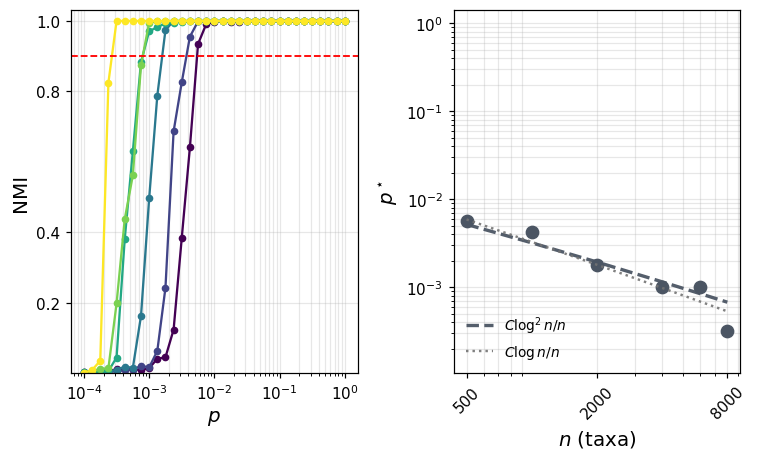

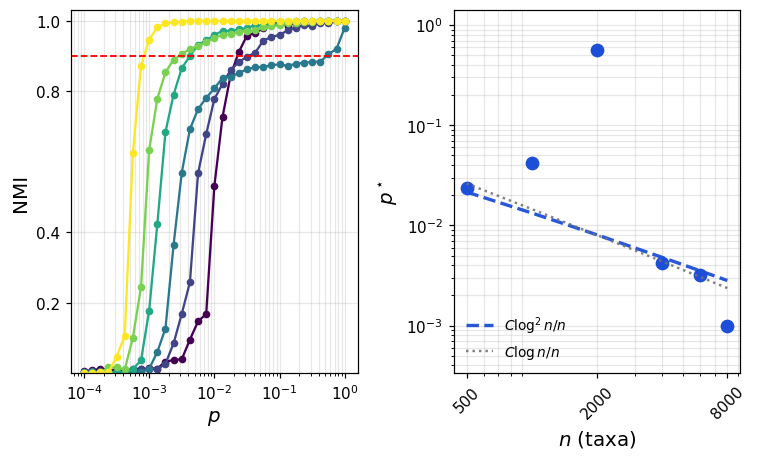

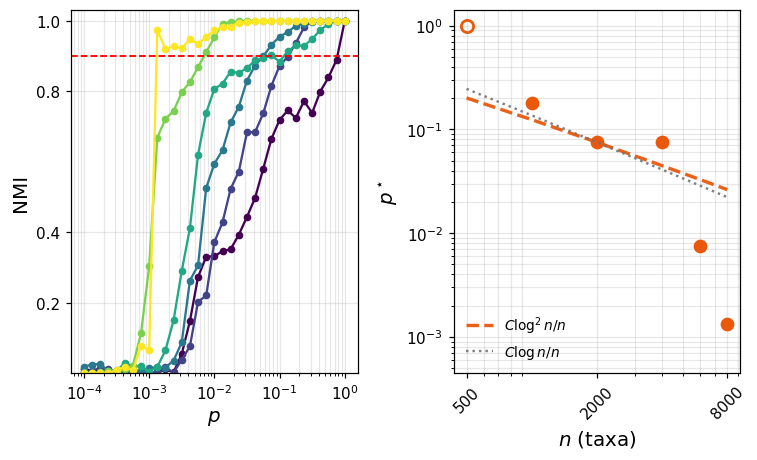

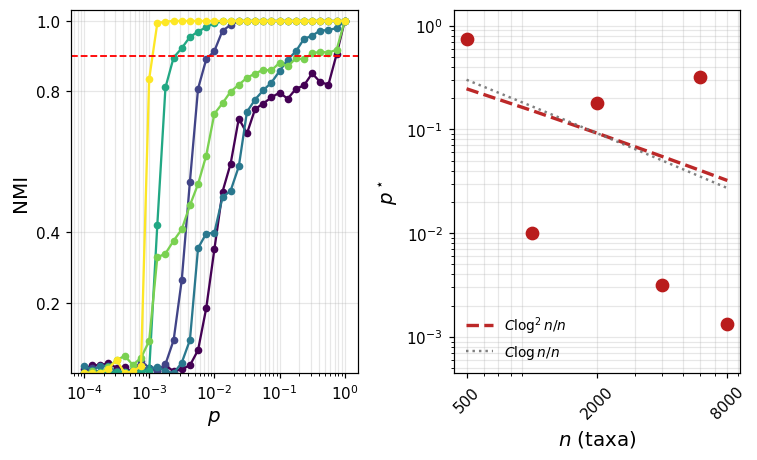

In [ ]:
# --- Diagnostic: does p*(n) read as C log n / n or C log^2 n / n? -----------
# Nothing here is a paper asset and nothing above is re-run: no savepath, so
# FIG_DIR is untouched. Same measured p* and same censoring rule as Cell 4 --
# only the reference curve changes.
#
# eq:main_rate is Theta(log m / m) only with beta_0 / (rho - eta*S_out^max) held
# FIXED in m. If the distance route's counterpart of that group -- d_0/tau_0,
# diameter over split separation -- grows with m, it multiplies through. It
# enters the Bernstein / Davis-Kahan step SQUARED (noise ~ d_0*sqrt(m log m / p)
# against a gap ~ m*tau_0), so d_0/tau_0 ~ log m gives log^3 n / n; log^2 n / n
# is what d_0/tau_0 ~ sqrt(log m) would give. Both curves use median-of-ratios.
from analysis.utils.sweep_plots_two_panel import (
    _draw_recovery_panel, FS_LABEL, FS_TICK, N_TICKS,
)
from analysis.utils.sweep_plots import ETA_COLORS, _label_n_axis
import matplotlib.pyplot as plt

ng_diag = np.array(sorted(ns), float)
G_LOG  = lambda x: np.log(x) / x
G_LOG2 = lambda x: np.log(x) ** 2 / x


def _median_ratio(xs, ys, g):
    """C = median_i p*_i / g(n_i), and spread = max_i r_i / min_i r_i."""
    r = ys / g(xs)
    return float(np.median(r)), float(r.max() / r.min())


_fits = {}
for eta in ETA_TARGETS:
    measured, censored = split_censored_pstar(pstar_dist.get(eta, []), P_VALUES,
                                              censor_floor=True)
    xs = np.array([n for n, _ in measured], float)
    ys = np.array([v for _, v in measured], float)
    _fits[eta] = (measured, censored,
                  _median_ratio(xs, ys, G_LOG), _median_ratio(xs, ys, G_LOG2))

print("median-of-ratios fit of the SAME measured p*, two candidate shapes")
print("spread = max/min of the per-point ratios: how badly one constant fits.\n")
print(f"{'eta':>4} {'n_meas':>7} | {'C (log n/n)':>12} {'spread':>7} |"
      f" {'C (log^2 n/n)':>14} {'spread':>7}")
for eta in ETA_TARGETS:
    meas, _, (c1, s1), (c2, s2) = _fits[eta]
    print(f"{eta:>4} {len(meas):>7} | {c1:>12.4g} {s1:>7.1f} |"
          f" {c2:>14.4g} {s2:>7.1f}")
print(f"\nn spans {min(ns)}..{max(ns)}, over which log n changes by only "
      f"{np.log(max(ns)) / np.log(min(ns)):.2f}x -- that factor IS the whole")
print("difference between the two references, and it is smaller than the")
print("per-point spread in every panel. This grid cannot separate the shapes.")

for eta in ETA_TARGETS:
    measured, censored, (C1, _), (C2, _) = _fits[eta]
    color = ETA_COLORS.get(eta, "black")
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.3))
    _draw_recovery_panel(axes[0], results_dist, np.array(P_VALUES), eta, ns,
                         agg=AGG, threshold=THRESHOLD, metric_label=METRIC_LABEL)
    ax = axes[1]
    if measured:
        ax.plot([n for n, _ in measured], [v for _, v in measured],
                marker="o", ls="none", ms=8, color=color)
    if censored:
        ax.plot([n for n, _ in censored], [v for _, v in censored],
                marker="o", ls="none", ms=8, mfc="none", mew=1.8, color=color)
    if len(measured) >= 2:
        ax.plot(ng_diag, C2 * G_LOG2(ng_diag), ls="--", lw=2.2, color=color,
                alpha=0.95, label=r"$C\log^2 n/n$")
        ax.plot(ng_diag, C1 * G_LOG(ng_diag), ls=":", lw=1.6, color="0.45",
                alpha=0.9, label=r"$C\log n/n$")
        ax.legend(fontsize=9, loc="lower left", frameon=False)
    ax.set_xscale("log"); ax.set_yscale("log")
    _label_n_axis(ax, np.array([t for t in N_TICKS
                                if ng_diag.min() <= t <= ng_diag.max()], float))
    ax.set_xlabel(r"$n$ (taxa)", fontsize=FS_LABEL)
    ax.set_ylabel(r"$p^\star$", fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.grid(True, which="both", alpha=0.3)
    _ys = [v for _, v in measured + censored]
    if _ys:
        ax.set_ylim(bottom=min(_ys) / 3.0, top=1.4)
    fig.tight_layout()
    plt.show()
